In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/indoor/Images'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_3.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.20796885234560156, 0.9527048655569782)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.4362408208175443, 0.6139564660691421)

In [10]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [11]:
each_accu=2*p*r/(p+r)
each_accu

airport_inside    0.963580
artstudio         0.926407
auditorium        0.955224
bakery            0.956661
bar               0.969050
                    ...   
tv_studio         0.919708
videostore        0.931818
waitingroom       0.905830
warehouse         0.971429
winecellar        0.988180
Length: 67, dtype: float64

In [12]:
targetF=[x  for x in each_accu.nsmallest(35).index.map(trainset.dataset.classess)]
targetF

[49,
 56,
 50,
 40,
 64,
 20,
 5,
 62,
 35,
 60,
 24,
 22,
 41,
 1,
 32,
 31,
 9,
 17,
 55,
 63,
 38,
 8,
 36,
 29,
 37,
 47,
 42,
 54,
 7,
 21,
 43,
 45,
 2,
 3,
 6]

In [13]:
#將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                        # if(softmax.max()<split_mode[2]):
                        #     indexF.append(idx.cpu().numpy().item())

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t in [4,54,2,20]):
                            indexT.append(idx.cpu().numpy().item()) 
                            
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        if(t in [4,54,2,20]):
                            indexF.append(idx.cpu().numpy().item()) 
                            
            torch.cuda.empty_cache() 
        return indexF,indexT

In [14]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('softmax',0.95)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(5672, 6824)

In [15]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(2190, 934)

In [16]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [17]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [18]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [20]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F' or data_name=='F_f'or data_name=='T_f'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

    elif(data_name=='F'):
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

    criterion = nn.CrossEntropyLoss()
    model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
   
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.4598638630554404,train_accu=0.7880121638924455
Epoch=0,valid_loss=0.6882977526105473,valid_accu=0.6440460947503202
0
Epoch=1,train_loss=0.3441349698776778,train_accu=0.8552336747759283
Epoch=1,valid_loss=0.572770223269542,valid_accu=0.7410371318822023
0
Epoch=2,train_loss=0.24634024746973596,train_accu=0.9085307298335468
Epoch=2,valid_loss=0.5460171193533151,valid_accu=0.7592829705505761
0
Epoch=3,train_loss=0.16724636739599263,train_accu=0.9503040973111395
Epoch=3,valid_loss=0.6588358199855887,valid_accu=0.7138284250960307
Epoch=4,train_loss=0.12881384146484462,train_accu=0.9592669654289373
Epoch=4,valid_loss=0.591217295003151,valid_accu=0.7528809218950064
Epoch=5,train_loss=0.07164574832096218,train_accu=0.9820742637644047
Epoch=5,valid_loss=0.6693015699960511,valid_accu=0.7410371318822023
Epoch=6,train_loss=0.06936386659402739,train_accu=0.9767925736235595
Epoch=6,valid_loss=0.670341326927864,valid_accu=0.7653649167733675
0
Epoch=7,train_loss=0.0511692159042411,

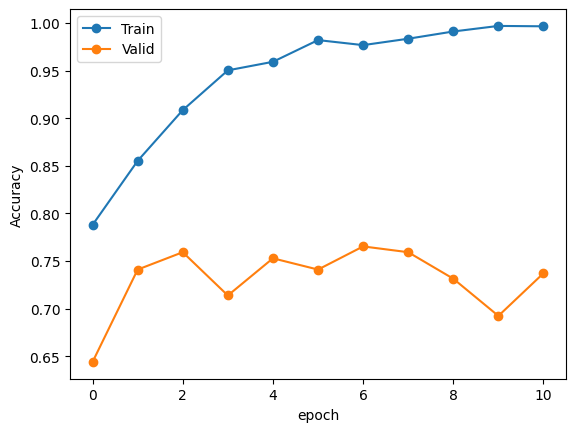

In [21]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70)

Epoch=0,train_loss=0.0690294653482971,train_accu=0.9856389214536928
Epoch=0,valid_loss=0.45314789771618885,valid_accu=0.9346895074946466
0
Epoch=1,train_loss=0.024133036135295178,train_accu=0.996189917936694
Epoch=1,valid_loss=0.49535154504402357,valid_accu=0.9389721627408993
0
Epoch=2,train_loss=0.01392435548572658,train_accu=0.9979484173505275
Epoch=2,valid_loss=0.5907199045142649,valid_accu=0.9357601713062098
Epoch=3,train_loss=0.005628943816700826,train_accu=0.9991207502930832
Epoch=3,valid_loss=0.5842986278658697,valid_accu=0.9421841541755889
0
Epoch=4,train_loss=0.008753726408316821,train_accu=0.9982415005861665
Epoch=4,valid_loss=0.6532375749807089,valid_accu=0.936830835117773
Epoch=5,train_loss=0.01254871020823442,train_accu=0.9972157092614302
Epoch=5,valid_loss=0.6329797373457364,valid_accu=0.9336188436830836
Epoch=6,train_loss=0.013718563452710213,train_accu=0.9966295427901524
Epoch=6,valid_loss=0.6710296392747913,valid_accu=0.9357601713062098
Epoch=7,train_loss=0.00564316023

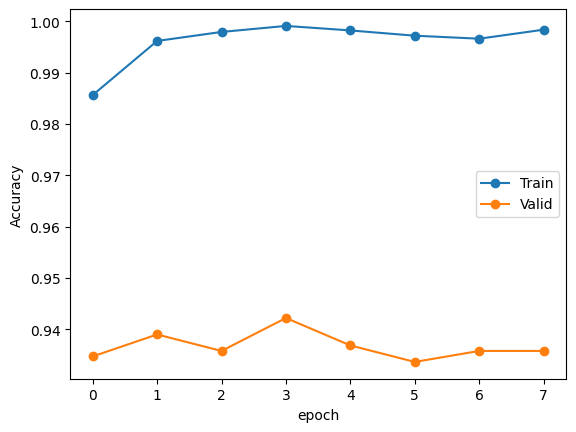

In [22]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.3174419413164404,train_accu=0.68811706629055
Epoch=0,valid_loss=2.175075209412945,valid_accu=0.4018264840182648
0
Epoch=1,train_loss=0.8694622054254723,train_accu=0.8050070521861777
Epoch=1,valid_loss=1.9456512673260415,valid_accu=0.4383561643835616
0
Epoch=2,train_loss=0.656149098668011,train_accu=0.8631875881523272
Epoch=2,valid_loss=1.868910812025201,valid_accu=0.4593607305936073
0
Epoch=3,train_loss=0.533782902658406,train_accu=0.8970380818053597
Epoch=3,valid_loss=1.8439611842098846,valid_accu=0.4748858447488584
0
Epoch=4,train_loss=0.44155265586332476,train_accu=0.9194287729196051
Epoch=4,valid_loss=1.850570655740015,valid_accu=0.4808219178082192
0
Epoch=5,train_loss=0.37705356218919095,train_accu=0.9361777150916785
Epoch=5,valid_loss=1.8580651184195254,valid_accu=0.4762557077625571
Epoch=6,train_loss=0.3250325376375438,train_accu=0.9479901269393513
Epoch=6,valid_loss=1.8454418689692946,valid_accu=0.4894977168949772
0
Epoch=7,train_loss=0.28187204509637254,tr

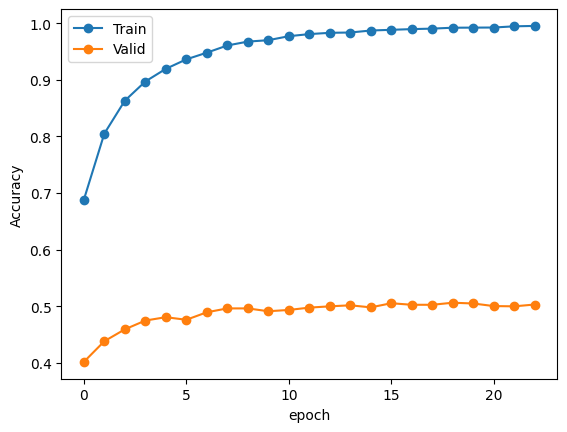

In [23]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [24]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.06536401430247459, 0.978393085787452)

In [25]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.670341326927864, 0.7653649167733675)

In [26]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.005628943764702892, 0.9991207502930832)

In [27]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.09720284130282396, 0.9920662905500706)

In [28]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.5842976958772099, 0.9421841541755889)

In [29]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(2.0001491331074335, 0.506392694063927)

In [30]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum_all=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum_all

(0.04719480540884823, 0.9959186939820742, 5672)

In [31]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum_all=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum_all

(1.5768451641830072, 0.6366837387964148, 2190)

In [32]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.05382320798322959, 0.9939180537772087, 5909, 6587)

In [33]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.6291230579649745, 0.6241997439180538, 1921, 1203)

In [34]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [35]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split_mode}')
df

split_mode = ('softmax', 0.95)


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.207969,0.952705,1.436241,0.613956
1,Model_Decision,0.065364,0.978393,0.065364,0.765365
2,Model_T,0.005629,0.999121,0.584298,0.942184
3,Model_F,0.097203,0.992066,2.000149,0.506393
4,Total_Model,0.053823,0.993918,1.629123,0.624200
5,Total_Model_without_decision,0.047195,0.995919,1.576845,0.636684


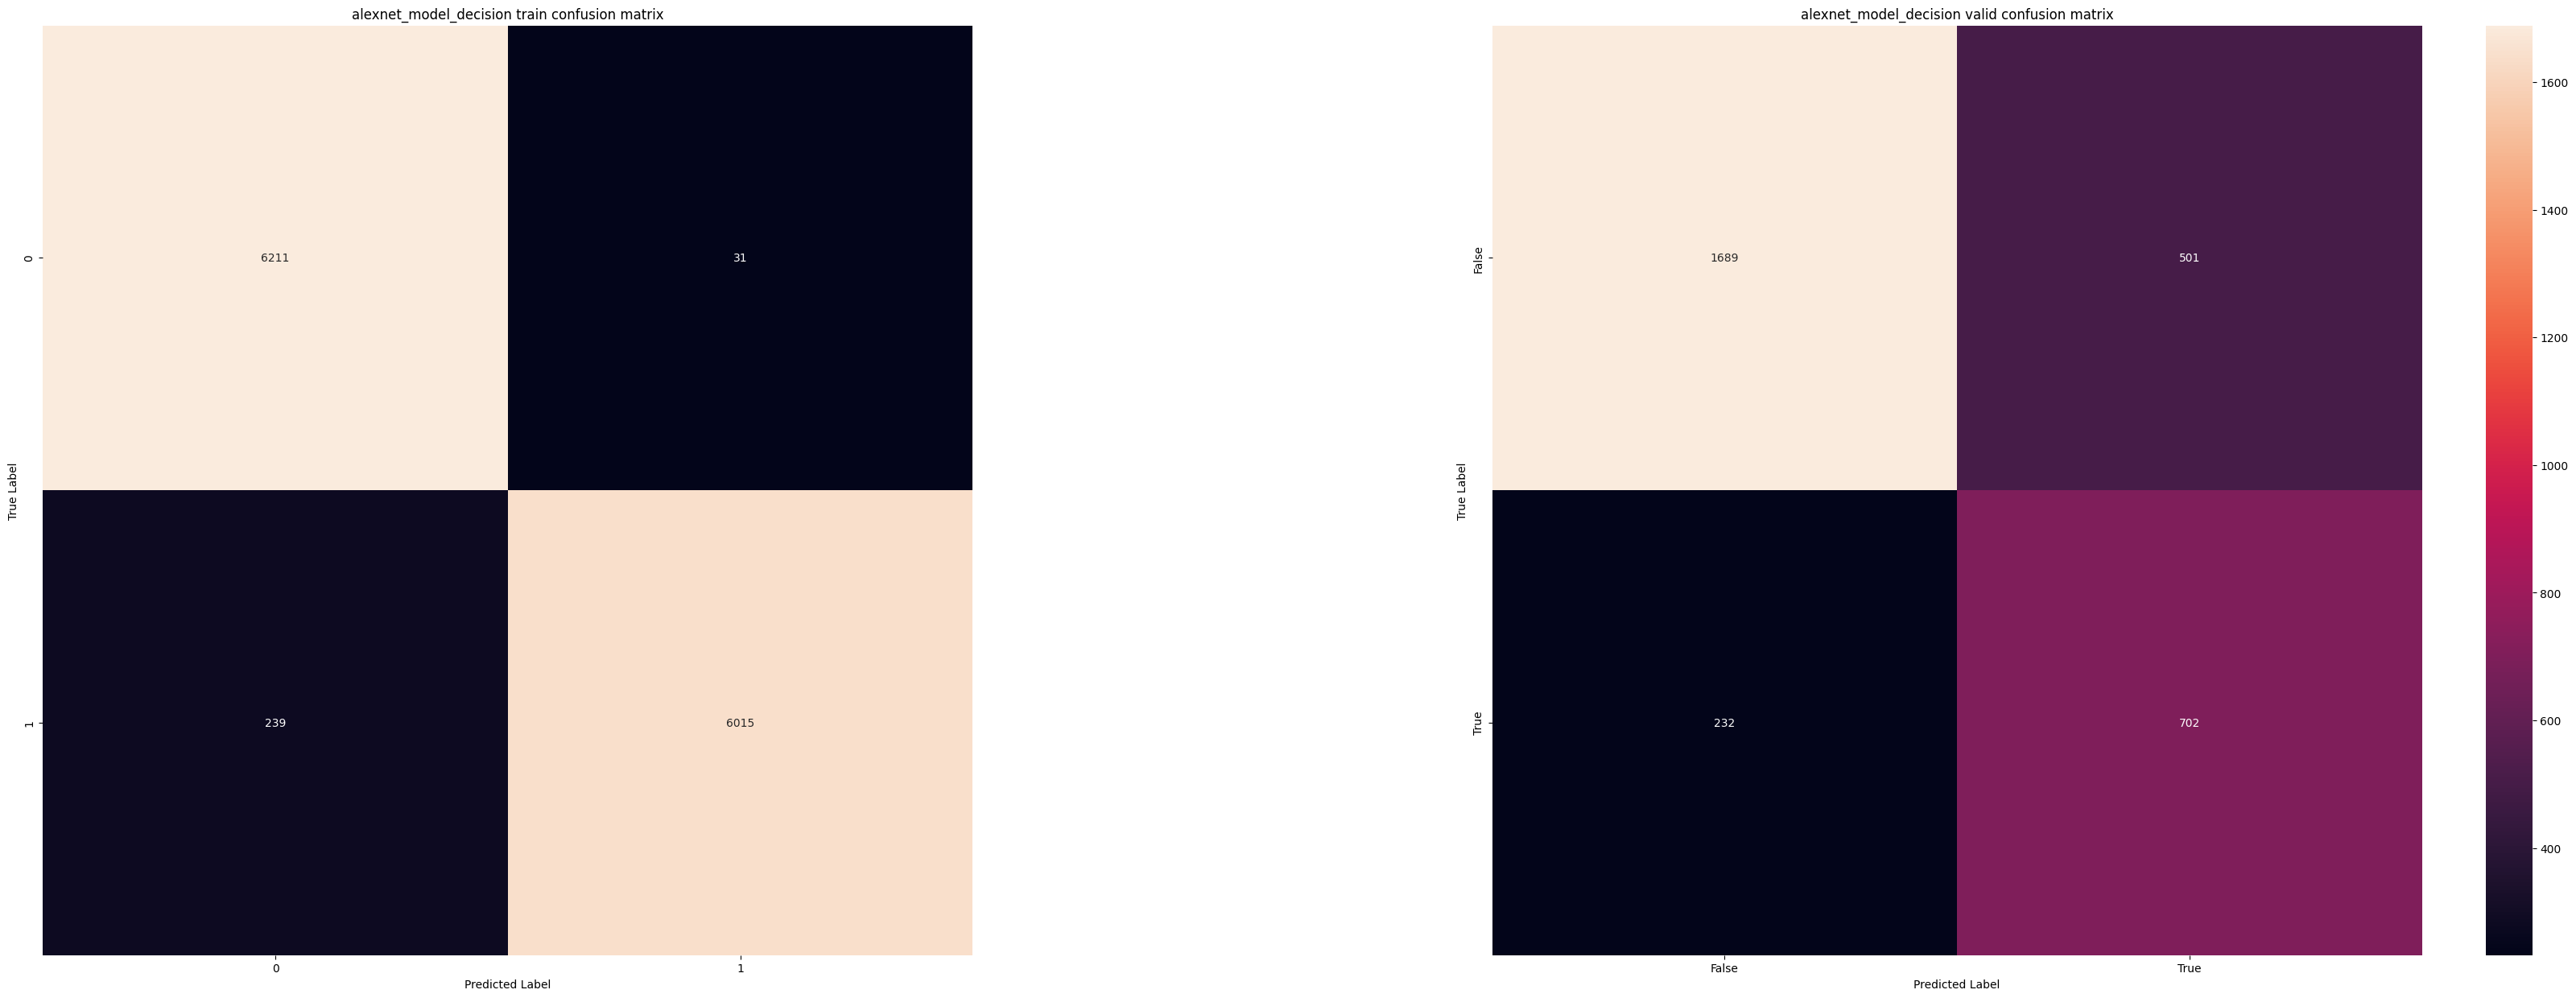

In [36]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

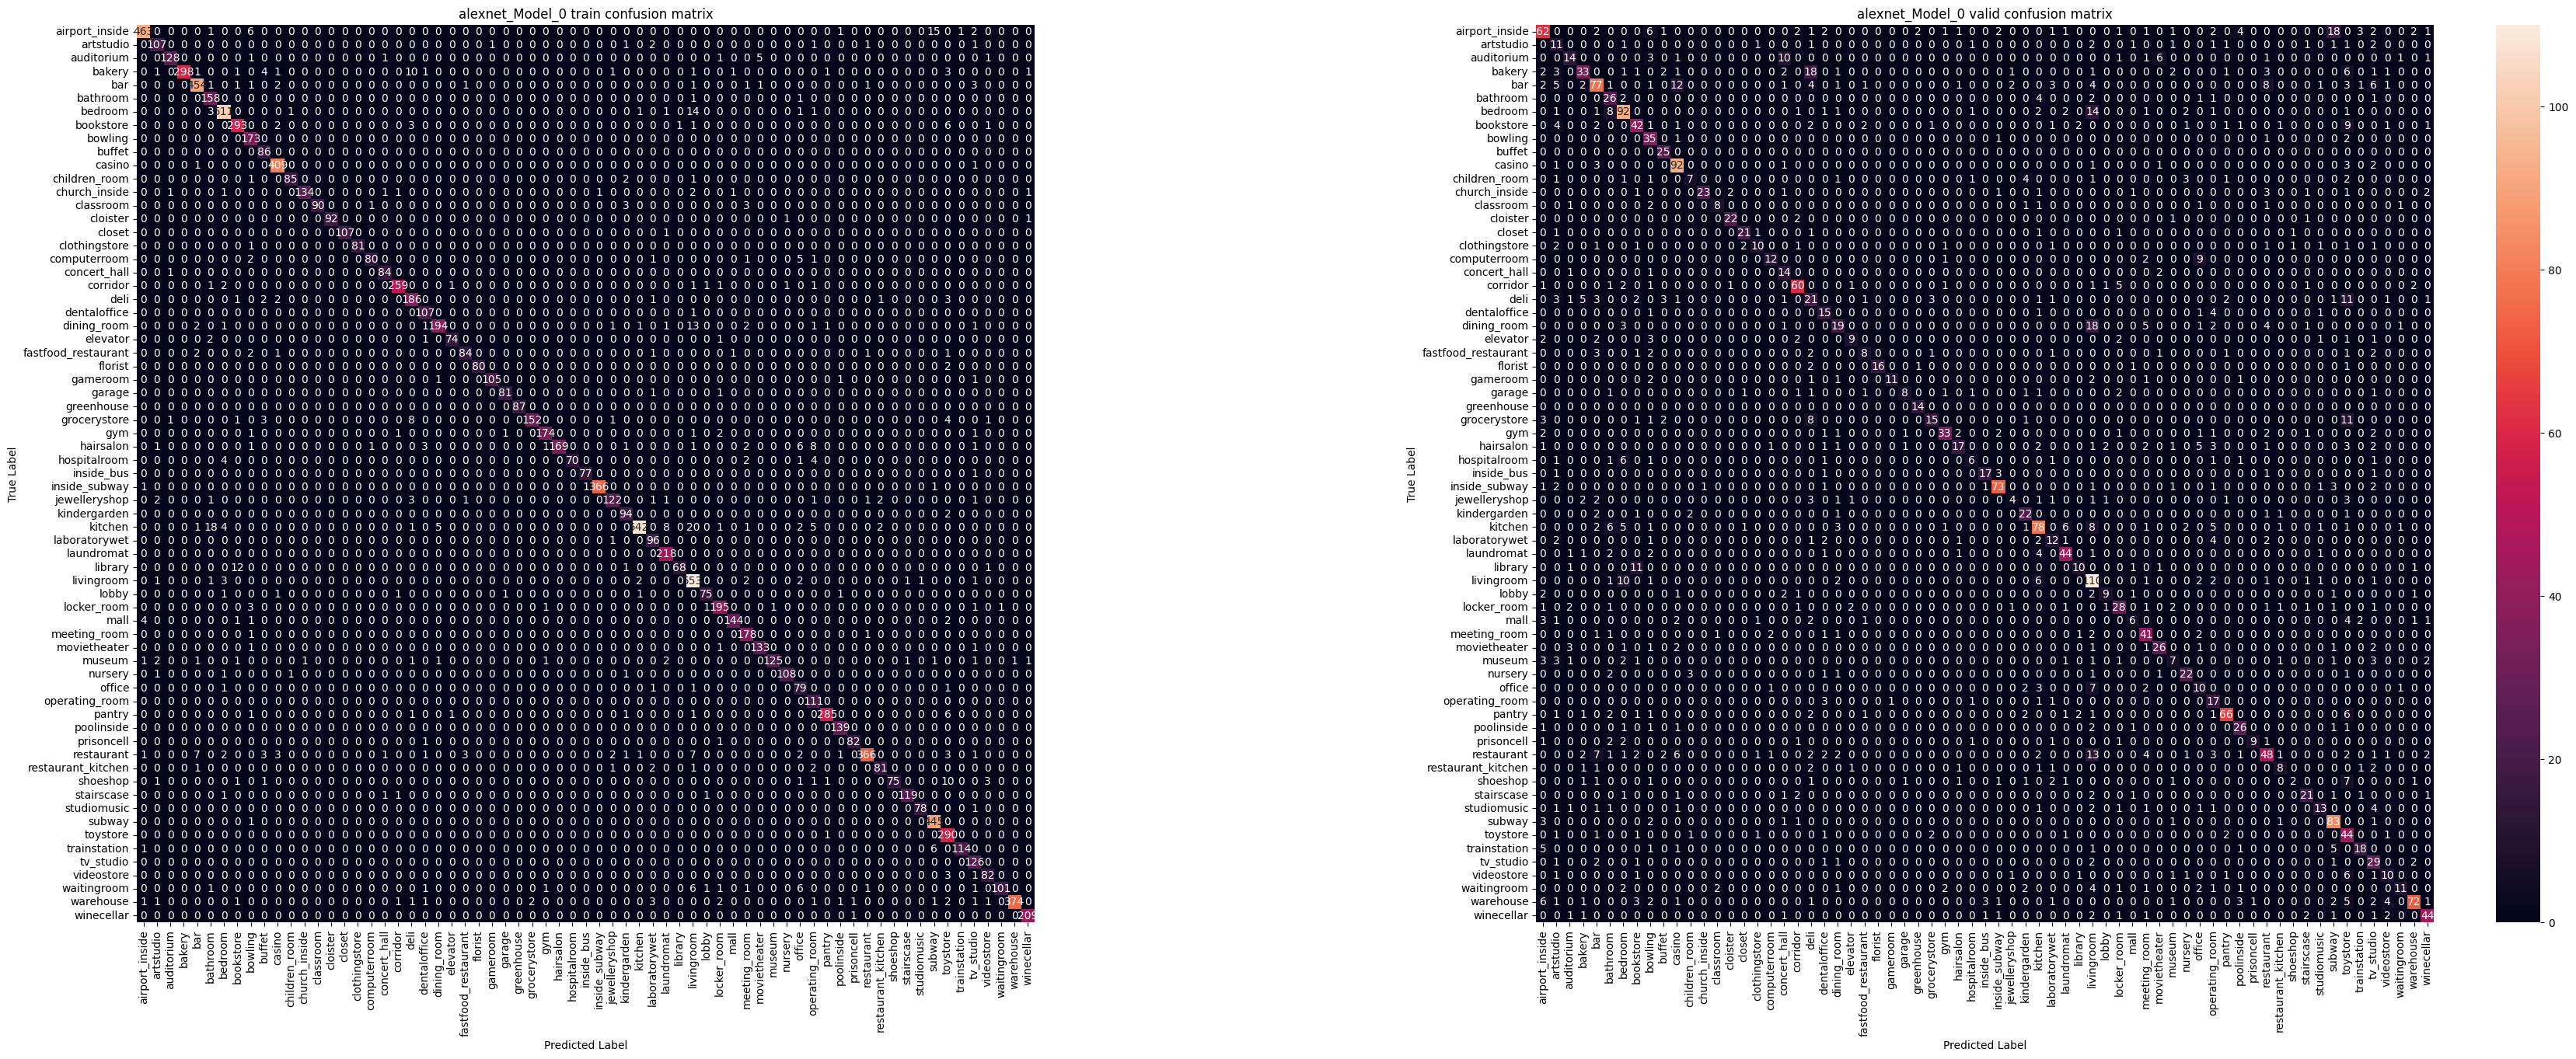

In [37]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

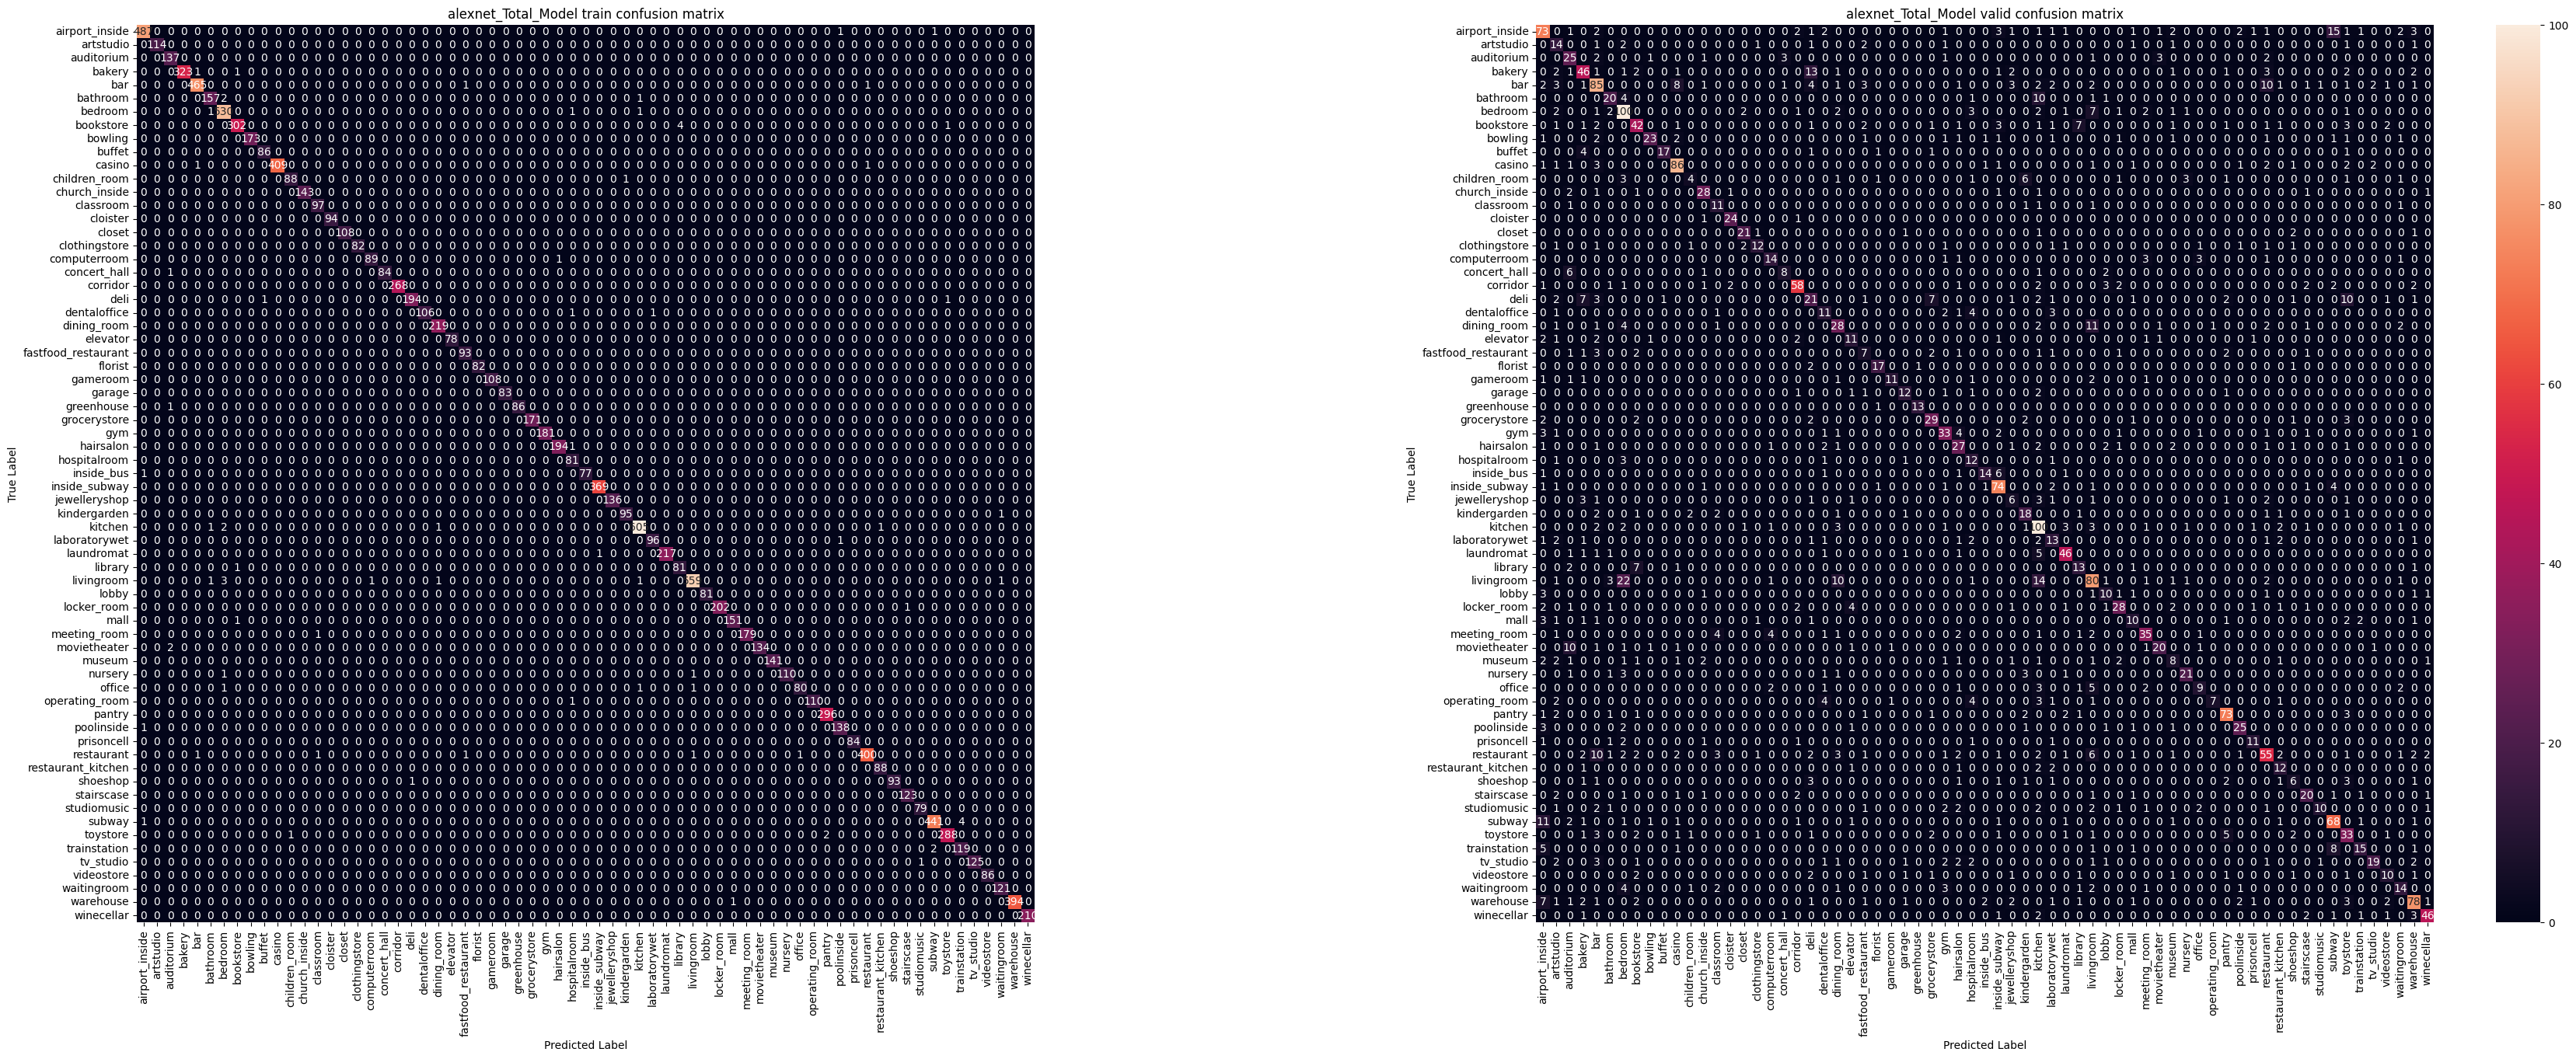

In [38]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

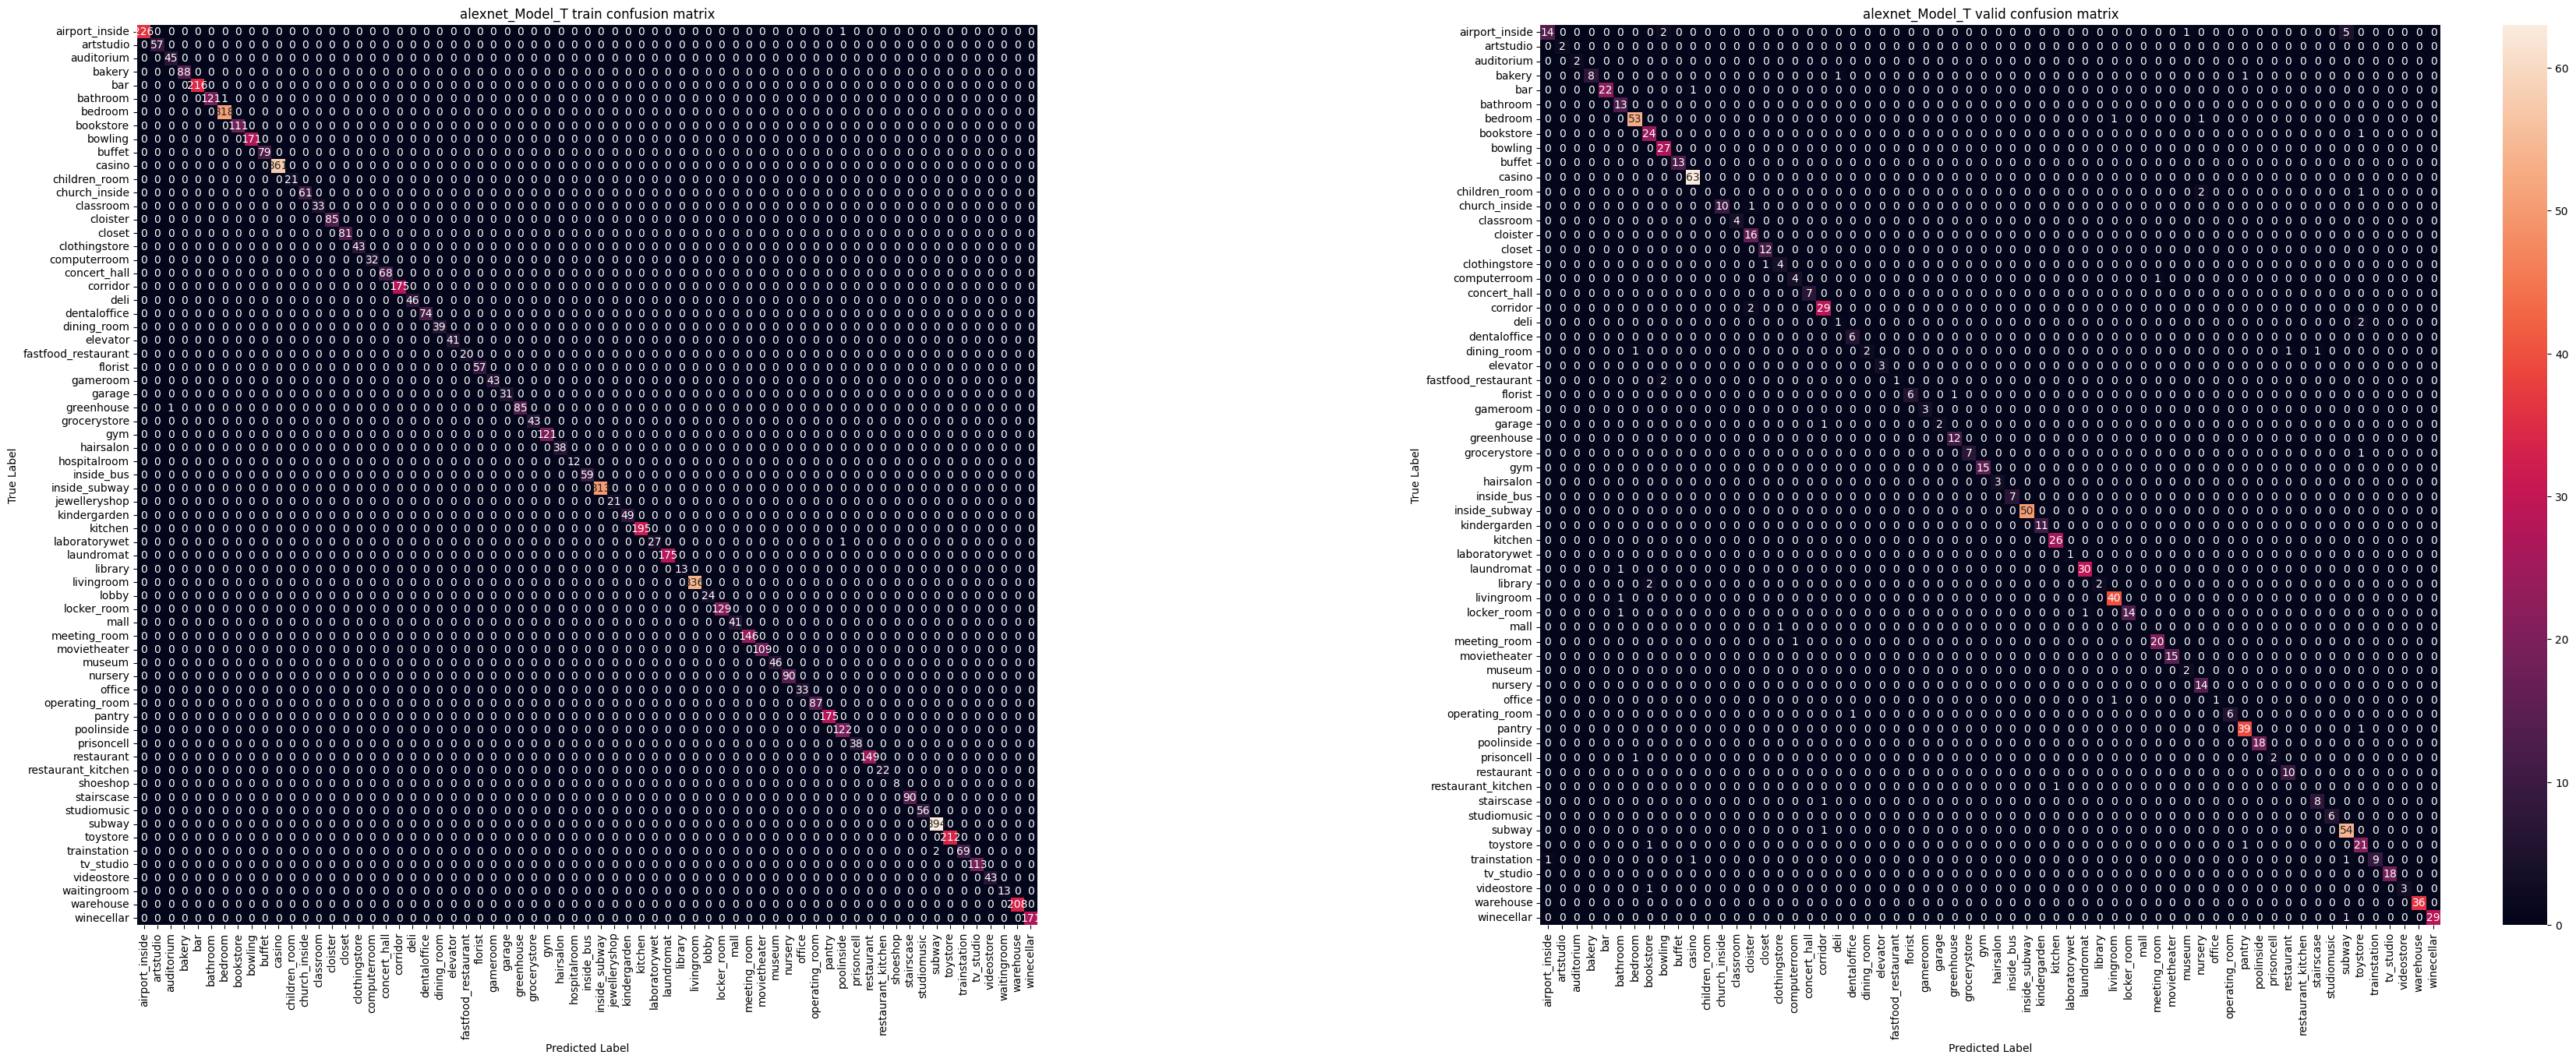

In [39]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

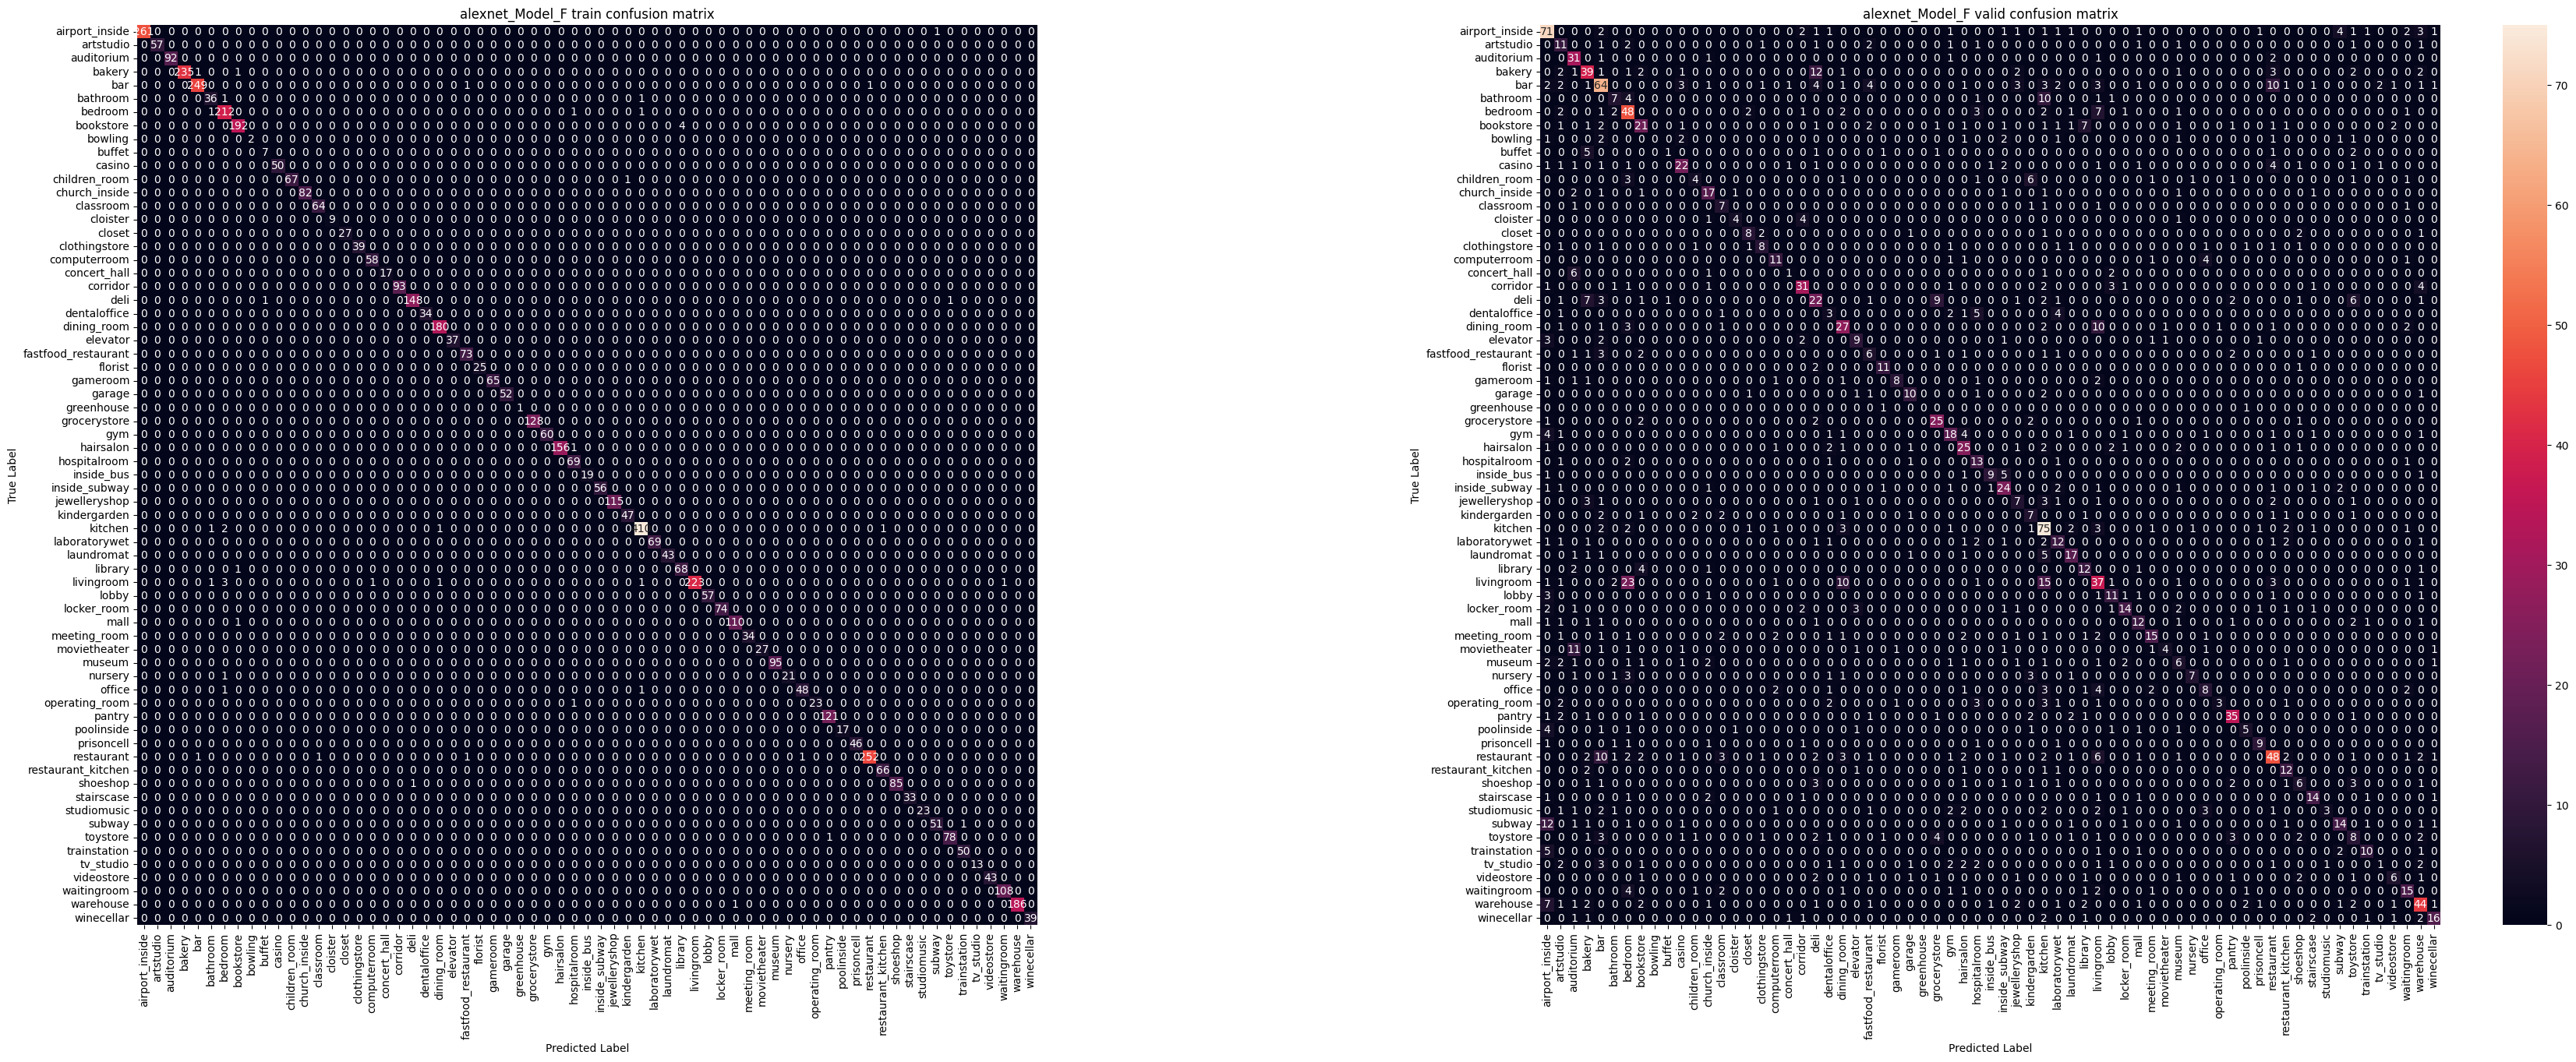

In [40]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [41]:
#全部模型裝在一起的表現
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()
                pred_T=torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                
                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item()
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [42]:
def calculate_zscore(softmax,avg,max_softmax,min_softmax):
    return (softmax-avg)/(max_softmax-min_softmax)

In [43]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [44]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,10958,45,45,45,45,0.987710,0.999994,0.998453,0.998187,True,True,True,True,True
1,14756,64,64,41,64,0.955517,0.739194,0.781063,0.949417,True,False,True,False,False
2,13785,59,0,59,59,0.835766,1.000000,0.999366,0.929705,False,True,True,True,True
3,8636,37,37,37,37,0.988544,0.837178,0.629207,0.999636,True,True,True,False,False
4,14436,62,62,54,62,0.996861,0.199735,0.928660,0.997163,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12491,15369,66,66,66,66,0.998309,0.999968,0.999328,0.999301,True,True,True,True,True
12492,6348,26,26,26,26,0.980146,0.996844,0.988950,0.820462,True,True,True,True,True
12493,6528,27,27,27,27,0.994792,0.995891,0.980855,0.787239,True,True,True,True,True
12494,13820,59,59,59,59,0.932864,0.999986,0.996670,0.999997,True,True,True,True,True


In [45]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

43    15
23    14
19    13
41    12
20    11
4     10
48    10
6      9
37     9
59     9
7      8
60     8
39     8
32     7
5      7
26     7
52     6
65     6
17     6
22     6
53     6
63     6
2      5
36     5
29     5
0      5
54     5
3      5
21     4
10     4
58     4
57     3
24     3
55     3
51     3
44     3
49     3
13     3
31     3
18     3
12     2
62     2
45     2
1      2
35     2
33     2
11     2
42     2
46     2
30     2
50     1
38     1
40     1
27     1
61     1
15     1
66     1
Name: Target, dtype: int64

In [46]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.85)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
53,15225,65,65,65,65,0.967304,0.639217,0.865796,0.579159,True,True,True,True,False
100,6722,29,29,29,29,0.992847,0.997222,0.952360,0.840103,True,True,True,False,True
111,14177,60,60,60,60,0.761914,0.999070,0.993453,0.754124,True,True,True,False,True
118,6148,24,24,24,24,0.967371,0.994345,0.989338,0.835806,True,True,True,False,True
146,863,2,2,2,2,0.985893,0.998104,0.963773,0.570036,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12276,11023,46,2,46,46,0.529382,0.965601,0.984415,0.575092,False,True,True,False,True
12284,6324,26,26,26,26,0.995812,0.999893,0.953766,0.746906,True,True,True,False,True
12373,13520,59,59,59,59,0.581284,0.999976,0.982822,0.561713,True,True,True,False,True
12386,12347,53,53,53,53,0.926065,0.999965,0.969125,0.680204,True,True,True,False,True


In [47]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
53,15225,65,65,65,65,0.967304,0.639217,0.865796,0.579159,True,True,True,True,False
100,6722,29,29,29,29,0.992847,0.997222,0.952360,0.840103,True,True,True,False,True
111,14177,60,60,60,60,0.761914,0.999070,0.993453,0.754124,True,True,True,False,True
118,6148,24,24,24,24,0.967371,0.994345,0.989338,0.835806,True,True,True,False,True
146,863,2,2,2,2,0.985893,0.998104,0.963773,0.570036,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12276,11023,46,2,46,46,0.529382,0.965601,0.984415,0.575092,False,True,True,False,True
12284,6324,26,26,26,26,0.995812,0.999893,0.953766,0.746906,True,True,True,False,True
12373,13520,59,59,59,59,0.581284,0.999976,0.982822,0.561713,True,True,True,False,True
12386,12347,53,53,53,53,0.926065,0.999965,0.969125,0.680204,True,True,True,False,True


In [48]:
df_results[df_results['Softmax_F'] >df_results['Softmax_T']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1,14756,64,64,41,64,0.955517,0.739194,0.781063,0.949417,True,False,True,False,False
3,8636,37,37,37,37,0.988544,0.837178,0.629207,0.999636,True,True,True,False,False
4,14436,62,62,54,62,0.996861,0.199735,0.928660,0.997163,True,False,True,False,False
5,13966,60,60,7,60,0.576485,0.333018,0.679486,0.820746,True,False,True,False,False
6,4982,18,18,18,18,0.971892,0.805028,0.937679,0.986491,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12478,4911,18,18,2,18,0.995229,0.538469,0.903193,0.999126,True,False,True,False,False
12483,10725,44,44,10,44,0.968742,0.958831,0.747384,0.994602,True,False,True,False,False
12486,9214,39,39,39,39,0.995178,0.646966,0.902316,0.995559,True,True,True,False,False
12488,13123,57,57,57,57,0.985530,0.937616,0.852281,0.996299,True,True,True,False,False


In [49]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,7028,30,30,30,62,0.993735,0.865784,0.633537,0.736080,True,True,False,True,False
1,12713,54,54,10,10,0.962389,0.994508,0.807364,0.979554,True,False,False,False,False
2,2521,6,6,6,41,0.605828,0.988072,0.582638,0.908844,True,True,False,True,False
3,5840,22,41,43,41,0.327412,0.415550,0.490003,0.832780,False,False,False,False,False
4,7356,32,27,38,38,0.284151,0.240034,0.218969,0.960204,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,6170,24,24,24,24,0.474974,0.993788,0.643570,0.966471,True,True,True,False,False
3120,4412,13,13,36,13,0.956337,0.571458,0.826852,0.939549,True,False,True,False,False
3121,10981,45,31,45,4,0.379941,0.396458,0.324873,0.995040,False,True,False,False,False
3122,1071,3,54,54,54,0.372083,0.536245,0.227639,0.962082,False,False,False,False,False


In [50]:
df=(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

0     54
4     36
41    31
10    30
59    28
      ..
24     2
49     1
28     1
32     1
56     1
Name: Target, Length: 67, dtype: int64

In [51]:
df_results_v[df_results_v['Decision']!=df_results_v['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,7028,30,30,30,62,0.993735,0.865784,0.633537,0.736080,True,True,False,True,False
2,2521,6,6,6,41,0.605828,0.988072,0.582638,0.908844,True,True,False,True,False
5,13456,59,66,2,59,0.614169,0.616572,0.605585,0.983528,False,False,True,True,False
6,11588,50,21,50,50,0.633788,0.982636,0.962854,0.904963,False,True,True,False,True
10,15076,65,65,65,65,0.975866,0.825688,0.609753,0.829351,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3096,6252,25,25,25,25,0.999234,0.954732,0.891405,0.999802,True,True,True,True,False
3108,10876,45,13,45,45,0.895929,0.985762,0.979174,0.864759,False,True,True,False,True
3109,1570,4,4,10,10,0.383280,0.849567,0.394114,0.831067,True,False,False,True,False
3114,3371,8,33,8,8,0.367663,0.999374,0.960413,0.719620,False,True,True,False,True
